In [ ]:
# P3 — Zero-Shot Aspect Detection for Hospital Reviews (EN + Banglish)
# Review-level Zero-Shot Aspect Detection + Sentence-level Sentiment (EN + Banglish)

!pip -q install transformers torch --upgrade
!pip -q install pandas numpy scikit-learn nltk tqdm

# 1) Imports, Drive, paths, helpers
import os, re, numpy as np, pandas as pd, torch
from tqdm import tqdm
tqdm.pandas()

# from google.colab import drive
# drive.mount('/content/drive')

# Unmount if anything is mounted
!fusermount -u /content/drive 2>/dev/null || true
# Remove any stray local folder/files created before mounting
!rm -rf /content/drive
!mkdir -p /content/drive

from google.colab import drive
drive.mount('/content/drive')



CSV_PATH = "/content/drive/MyDrive/Dhaka.csv"
OUT_DIR  = "/content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot"
os.makedirs(OUT_DIR, exist_ok=True)

def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = re.sub(r"<[^>]+>", " ", s)              # strip HTML
    s = re.sub(r"[\u200b\u200c\u200d]", " ", s) # zero-widths
    s = re.sub(r"\s+", " ", s).strip().lower()
    # tame elongations common in Banglish: "soooo bad" -> "soo bad"
    s = re.sub(r"(.)\1{2,}", r"\1\1", s)
    return s

def minmax_safe(x: pd.Series):
    x = x.astype(float)
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else pd.Series(np.zeros(len(x)), index=x.index)

# 2) Load CSV (robust)
try:
    df = pd.read_csv(CSV_PATH)
except Exception as e:
    print("Strict read failed, retrying with on_bad_lines='skip' ...", e)
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")

required = {"Hospital", "Review", "Sentiment"}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

keep_cols = [c for c in ["Division","District","Hospital","Review","Sentiment"] if c in df.columns]
df = df[keep_cols].copy()
df["Review"] = df["Review"].fillna("").apply(clean_text)

def norm_sent(x):
    s = str(x).strip().lower()
    if s in {"-1","neg","negative"}: return -1
    if s in {"1","pos","positive"}:  return 1
    return 0
df["Sentiment"] = df["Sentiment"].apply(norm_sent)

print(df.head(3))
print("Rows:", len(df), "| Columns:", df.columns.tolist())

# 3) Zero-shot aspect detection (multilingual NLI)
#PATCHED ZERO-SHOT SECTION (safe for empty reviews / last-batch issues)

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Model (multilingual; good for EN + Banglish). For faster EN-only, use: 'facebook/bart-large-mnli'
MODEL_NAME = "joeddav/xlm-roberta-large-xnli"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = 0 if torch.cuda.is_available() else -1
zshot = pipeline("zero-shot-classification", model=model, tokenizer=tokenizer, device=device)

# Candidate labels phrased to cover each aspect
CANDIDATE_LABELS = [
    "cleanliness and hygiene",
    "affordability and cost and billing",
    "treatment quality and diagnosis and medical care",
    "service quality and staff behavior and waiting time",
]
ASPECT_KEYS = ["cleanliness", "affordability", "treatment_quality", "service_quality"]
THRESHOLDS = {k: 0.40 for k in ASPECT_KEYS}
HYPOTHESIS_TEMPLATE = "This review is about {}."

# 1) Ensure cleaned text exists and make a non-empty mask
if "Review" not in df.columns:
    raise ValueError("Expected 'Review' column in df.")
df["Review"] = df["Review"].fillna("").apply(clean_text)
valid_mask = df["Review"].str.len() > 2
valid_idx  = df.index[valid_mask].tolist()
texts_valid = df.loc[valid_idx, "Review"].tolist()

# 2) Safe batched zero-shot over only non-empty reviews
from tqdm import tqdm

def zero_shot_batch_safe(texts, batch_size=8):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Zero-shot"):
        batch = texts[i:i+batch_size]
        if not batch:   # guard: skip accidental empty slice
            continue
        out = zshot(
            batch,
            candidate_labels=CANDIDATE_LABELS,
            multi_label=True,
            hypothesis_template=HYPOTHESIS_TEMPLATE
        )
        if isinstance(out, dict):  # when batch_size==1, pipeline returns a dict
            out = [out]
        results.extend(out)
    return results

zs_results_valid = zero_shot_batch_safe(texts_valid, batch_size=8)

# 3) Convert zero-shot outputs -> aspect flags/scores
def extract_aspect_flags(zs_output):
    labels = zs_output["labels"]
    scores = zs_output["scores"]
    label2score = {lab: sc for lab, sc in zip(labels, scores)}
    out = {}
    for label, aspect in zip(CANDIDATE_LABELS, ASPECT_KEYS):
        score = float(label2score.get(label, 0.0))
        out[f"zs_{aspect}_score"] = score
        out[f"has_{aspect}"] = 1 if score >= THRESHOLDS[aspect] else 0
    return out

rows_valid = [extract_aspect_flags(r) for r in zs_results_valid]

# 4) Allocate full-size result frame (zeros), then fill only valid rows
zeros = {
    **{f"zs_{a}_score": 0.0 for a in ASPECT_KEYS},
    **{f"has_{a}": 0 for a in ASPECT_KEYS},
}
zs_full = pd.DataFrame([zeros] * len(df), index=df.index)

zs_valid_df = pd.DataFrame(rows_valid, index=valid_idx)
for col in zs_valid_df.columns:
    zs_full.loc[valid_idx, col] = zs_valid_df[col].values

# 5) Merge into main DF
df_aspects = pd.concat([df.reset_index(drop=True), zs_full.reset_index(drop=True)], axis=1)

# 6) Aspect sentiment per review: use existing review-level Sentiment when aspect present, else 0
for aspect in ASPECT_KEYS:
    df_aspects[f"{aspect}_sentiment"] = np.where(
        df_aspects[f"has_{aspect}"] == 1, df_aspects["Sentiment"].astype(float), 0.0
    )

print("Per-review preview:")
print(df_aspects.head(5).to_string(index=False))

# 4) Per-hospital aggregation & scoring
GROUP_BY_DISTRICT = False  # set True to group by ['District','Hospital'] if needed

def compute_hospital_table(df_):
    group_cols = ["Hospital"] if not GROUP_BY_DISTRICT or "District" not in df_.columns else ["District","Hospital"]
    g = df_.groupby(group_cols, dropna=False)
    rows = []
    for key, sub in g:
        hosp_name = key if isinstance(key, str) else " | ".join(map(str, key))
        N = len(sub)
        avg_sent = sub["Sentiment"].mean() if N>0 else 0.0
        S = (avg_sent + 1.0)/2.0

        rec = {"Hospital": hosp_name, "N_reviews": N, "S": S}

        for asp, short in [("cleanliness","C"),
                           ("affordability","A"),
                           ("treatment_quality","TQ"),
                           ("service_quality","SQ")]:
            mention = sub[f"has_{asp}"].sum()
            mention_frac = (mention / N) if N>0 else 0.0
            avg_as = sub.loc[sub[f"has_{asp}"]==1, f"{asp}_sentiment"].mean() if mention>0 else 0.0
            raw = mention_frac * ((avg_as + 1.0)/2.0)
            rec[f"raw_{short}"] = raw
            rec[f"{short}_mention_frac"] = mention_frac
            rec[f"zs_{short}_avgscore"] = sub[f"zs_{asp}_score"].mean()

        rows.append(rec)

    H = pd.DataFrame(rows)

    # Normalize aspects across hospitals
    for short in ["C","A","TQ","SQ"]:
        H[short] = minmax_safe(H[f"raw_{short}"])

    # Confidence from volume
    H["conf"] = np.log1p(H["N_reviews"])
    H["conf"] = H["conf"] / H["conf"].max() if H["conf"].max() > 0 else 0.0

    return H

H = compute_hospital_table(df_aspects)
print("\nPer-hospital preview:")
print(H.sort_values("S", ascending=False).head(10).to_string(index=False))

# 5) Unified score + ranking
w_S, w_C, w_A, w_TQ, w_SQ = 0.25, 0.20, 0.15, 0.25, 0.15  # weights sum to 1
alpha = 0.85  # confidence floor

H["base_score"]  = (w_S*H["S"] + w_C*H["C"] + w_A*H["A"] + w_TQ*H["TQ"] + w_SQ*H["SQ"])
H["final_score"] = H["base_score"] * (alpha + (1 - alpha)*H["conf"])

H_ranked = H.sort_values("final_score", ascending=False).reset_index(drop=True)
print("\nTop-20 (final_score):")
print(H_ranked.head(20).to_string(index=False))

# 6) Top-3 by each aspect (for slides)
def topk_by_col(df_, col, k=3):
    return df_.sort_values(col, ascending=False).head(k)[["Hospital", col, "N_reviews"]]

print("\nTop-3 by Sentiment (S):")
print(topk_by_col(H, "S").to_string(index=False))

print("\nTop-3 by Cleanliness (C):")
print(topk_by_col(H, "C").to_string(index=False))

print("\nTop-3 by Affordability (A):")
print(topk_by_col(H, "A").to_string(index=False))

print("\nTop-3 by Treatment Quality (TQ):")
print(topk_by_col(H, "TQ").to_string(index=False))

print("\nTop-3 by Service Quality (SQ):")
print(topk_by_col(H, "SQ").to_string(index=False))

# 7) Save outputs
per_review_out   = os.path.join(OUT_DIR, "reviews_with_zeroshot_aspects.csv")
per_hospital_out = os.path.join(OUT_DIR, "hospital_scores_zeroshot.csv")
df_aspects.to_csv(per_review_out, index=False)
H_ranked.to_csv(per_hospital_out, index=False)
print("\nSaved:")
print(per_review_out)
print(per_hospital_out)


Mounted at /content/drive
Strict read failed, retrying with on_bad_lines='skip' ... Error tokenizing data. C error: Expected 5 fields in line 722, saw 7

  Division District                                          Hospital  \
0    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   
1    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   
2    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   

                                              Review  Sentiment  
0  if you can consider the spaciousness and clean...         -1  
1  worst place to go for treatment. strongly advi...         -1  
2  nice environment inside. well maintained clear...          1  
Rows: 10035 | Columns: ['Division', 'District', 'Hospital', 'Review', 'Sentiment']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Zero-shot: 100%|██████████| 1245/1245 [10:01<00:00,  2.07it/s]


Per-review preview:
Division District                                         Hospital                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Review  Sentiment  zs_cleanliness_score  zs_affordability_score  zs_treatme

In [ ]:
# Top-3 Hospitals per Aspect (REVIEW-LEVEL)

import os, pandas as pd

# Config
ASPECT_KEYS = ["cleanliness", "affordability", "treatment_quality", "service_quality"]
SHORT = {"cleanliness":"C", "affordability":"A", "treatment_quality":"TQ", "service_quality":"SQ"}
TOPK = 3
MIN_REVIEWS = 0   # set to 5 if want the ≥5 filter here too

# grab an in-memory review-level dataframe; else load from Drive
H_rv = None
for varname in ["H_rv", "H"]:
    if varname in globals():
        tmp = globals()[varname]
        if isinstance(tmp, pd.DataFrame) and {"Hospital","N_reviews"}.issubset(tmp.columns):
            H_rv = tmp.copy()
            break

if H_rv is None:
    RV_HOSP_CSV = "/content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot/hospital_scores_zeroshot.csv"
    H_rv = pd.read_csv(RV_HOSP_CSV)

# Optional, require a minimum number of reviews
if MIN_REVIEWS and "N_reviews" in H_rv.columns:
    H_rv = H_rv[H_rv["N_reviews"] >= MIN_REVIEWS].copy()

def topk_hospitals_by_aspect(H, aspect, k=3):
    col = SHORT[aspect]
    cols = ["Hospital","N_reviews","S",col] + (["conf"] if "conf" in H.columns else [])
    out = H.sort_values(col, ascending=False)[cols].head(k).reset_index(drop=True)
    out.rename(columns={col: f"{col}_score"}, inplace=True)
    return out

tables = []
print("=== TOP-3 HOSPITALS BY ASPECT (Review-level) ===")
for asp in ASPECT_KEYS:
    print(f"\n>> Aspect: {asp}  (score col: {SHORT[asp]})")
    topk = topk_hospitals_by_aspect(H_rv, asp, k=TOPK)
    display(topk)
    topk.insert(0, "aspect", asp)
    tables.append(topk)

all_top = pd.concat(tables, ignore_index=True)
save_path = "/content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot/top3_per_aspect_reviewlevel.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
all_top.to_csv(save_path, index=False)
print("\nSaved:", save_path)


=== TOP-3 HOSPITALS BY ASPECT (Review-level) ===

>> Aspect: cleanliness  (score col: C)


,Hospital,N_reviews,S,C_score,conf
0,Central Hospital Rajbari,1,1.0,1.0,0.123729
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Saleha Mothercare Hospital,1,1.0,1.0,0.123729



>> Aspect: affordability  (score col: A)


,Hospital,N_reviews,S,A_score,conf
0,Dr Farid Memorial Hospital,3,1.0,1.00,0.247459
1,Saleha Mothercare Hospital,1,1.0,1.00,0.123729
2,Doyel Medical Centre,10,0.8,0.85,0.428034



>> Aspect: treatment_quality  (score col: TQ)


,Hospital,N_reviews,S,TQ_score,conf
0,Faridpur Maa O Shishu General Hospital Ltd,3,1.0,1.0,0.247459
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Central Hospital Rajbari,1,1.0,1.0,0.123729



>> Aspect: service_quality  (score col: SQ)


,Hospital,N_reviews,S,SQ_score,conf
0,Central Hospital Rajbari,1,1.0,1.0,0.123729
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Saleha Mothercare Hospital,1,1.0,1.0,0.123729



Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot/top3_per_aspect_reviewlevel.csv


In [ ]:
# Sentence-level Zero-Shot Aspect Detection + Sentence-level Sentiment (EN + Banglish)

!pip -q install transformers torch --upgrade
!pip -q install pandas numpy scikit-learn nltk tqdm

import os, re, numpy as np, pandas as pd, torch
from tqdm import tqdm
tqdm.pandas()

from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/Dhaka.csv"
OUT_DIR  = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
os.makedirs(OUT_DIR, exist_ok=True)

# Controls (tune if needed)
ZS_MODEL  = "joeddav/xlm-roberta-large-xnli"     # Multilingual NLI (good for EN + Banglish). Faster EN-only: 'facebook/bart-large-mnli'
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # Multilingual sentiment (maps to neg/neu/pos)
ZS_BATCH  = 8          # lower if hit OOM
SENT_BATCH= 16         # lower if hit OOM
ASPECT_THRESH = {a:0.40 for a in ["cleanliness","affordability","treatment_quality","service_quality"]}
HYPOTHESIS_TEMPLATE = "This sentence is about {}."
MAX_SENTS_PER_REVIEW = None  # e.g., 8 to cap long reviews (None = use all sentences)

# 1) Helpers
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = re.sub(r"<[^>]+>", " ", s)              # strip HTML
    s = re.sub(r"[\u200b\u200c\u200d]", " ", s) # zero-widths
    s = re.sub(r"\s+", " ", s).strip().lower()
    # tame elongations common in Banglish: "soooo bad" -> "soo bad"
    s = re.sub(r"(.)\1{2,}", r"\1\1", s)
    return s

def minmax_safe(x: pd.Series):
    x = x.astype(float)
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else pd.Series(np.zeros(len(x)), index=x.index)

# 2) Load CSV
try:
    df = pd.read_csv(CSV_PATH)
except Exception as e:
    print("Strict read failed, retrying with on_bad_lines='skip' ...", e)
    df = pd.read_csv(CSV_PATH, on_bad_lines="skip")

required = {"Hospital", "Review", "Sentiment"}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

keep_cols = [c for c in ["Division","District","Hospital","Review","Sentiment"] if c in df.columns]
df = df[keep_cols].copy()
df["Review"] = df["Review"].fillna("").apply(clean_text)

def norm_sent(x):
    s = str(x).strip().lower()
    if s in {"-1","neg","negative"}: return -1
    if s in {"1","pos","positive"}:  return 1
    return 0
df["Sentiment"] = df["Sentiment"].apply(norm_sent)

print(df.head(3))
print("Rows:", len(df), "| Columns:", df.columns.tolist())

# 3) Sentence splitting
import nltk
nltk.download('punkt', quiet=True)
def split_sents(txt):
    try:
        sents = nltk.tokenize.sent_tokenize(txt)
    except:
        sents = re.split(r"[.!?।]+", txt)
    sents = [s.strip() for s in sents if len(s.strip()) > 2]
    if MAX_SENTS_PER_REVIEW is not None and len(sents) > MAX_SENTS_PER_REVIEW:
        sents = sents[:MAX_SENTS_PER_REVIEW]  # keep first N for speed
    return sents

df = df.reset_index(drop=False).rename(columns={"index":"rid"})  # rid = review id
rows = []
for _, r in tqdm(df.iterrows(), total=len(df), desc="Split to sentences"):
    sents = split_sents(r["Review"])
    for sid, s in enumerate(sents):
        rows.append({"rid": r["rid"], "Hospital": r["Hospital"], "sentence": s})
df_s = pd.DataFrame(rows)
print("Sentence rows:", len(df_s))

# 4) Zero-shot per sentence (multi-label)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

zs_tokenizer = AutoTokenizer.from_pretrained(ZS_MODEL)
zs_model     = AutoModelForSequenceClassification.from_pretrained(ZS_MODEL)
device = 0 if torch.cuda.is_available() else -1
zshot = pipeline("zero-shot-classification", model=zs_model, tokenizer=zs_tokenizer, device=device)

CANDIDATE_LABELS = [
    "cleanliness and hygiene",
    "affordability and cost and billing",
    "treatment quality and diagnosis and medical care",
    "service quality and staff behavior and waiting time",
]
ASPECT_KEYS = ["cleanliness", "affordability", "treatment_quality", "service_quality"]

def zshot_batch(texts, bs=ZS_BATCH):
    out_all = []
    for i in tqdm(range(0, len(texts), bs), desc="Zero-shot (sentences)"):
        batch = texts[i:i+bs]
        if not batch: continue
        out = zshot(batch, candidate_labels=CANDIDATE_LABELS, multi_label=True, hypothesis_template=HYPOTHESIS_TEMPLATE)
        if isinstance(out, dict): out = [out]
        out_all.extend(out)
    return out_all

zs_res = zshot_batch(df_s["sentence"].tolist())

def zshot_to_cols(res):
    labels, scores = res["labels"], res["scores"]
    mp = {lab: sc for lab, sc in zip(labels, scores)}
    d = {}
    for lab, asp in zip(CANDIDATE_LABELS, ASPECT_KEYS):
        sc = float(mp.get(lab, 0.0))
        d[f"zs_{asp}_score"] = sc
        d[f"has_{asp}"] = 1 if sc >= ASPECT_THRESH[asp] else 0
    return d

zs_df = pd.DataFrame([zshot_to_cols(r) for r in zs_res])
df_s = pd.concat([df_s.reset_index(drop=True), zs_df.reset_index(drop=True)], axis=1)

# 5) Sentence-level sentiment
from transformers import AutoModelForSequenceClassification as SCls

sent_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
sent_model     = SCls.from_pretrained(SENT_MODEL)
sent_pipe = pipeline("text-classification", model=sent_model, tokenizer=sent_tokenizer, device=device, return_all_scores=False)

def sent_batch(texts, bs=SENT_BATCH):
    labs = []
    for i in tqdm(range(0, len(texts), bs), desc="Sentence sentiment"):
        batch = texts[i:i+bs]
        if not batch: continue
        out = sent_pipe(batch, truncation=True)
        if isinstance(out, dict): out = [out]
        for item in out:
            # cardiffnlp returns labels: NEGATIVE/NEUTRAL/POSITIVE
            lab = item["label"].lower()
            if "neg" in lab: labs.append(-1)
            elif "pos" in lab: labs.append(1)
            else: labs.append(0)
    return labs

df_s["sentiment_sentence"] = sent_batch(df_s["sentence"].tolist())

# 6) Aggregate sentence -> review per aspect
# For each review & aspect: has_<aspect> = any sentence has it; <aspect>_sentiment = mean of sentence sentiments where has_<aspect>=1 (else 0)
def agg_review_aspects(df_s):
    # Build per-aspect metrics
    outs = []
    for rid, sub in df_s.groupby("rid"):
        row = {"rid": rid}
        for asp in ASPECT_KEYS:
            has_col = f"has_{asp}"
            mask = sub[has_col] == 1
            row[f"has_{asp}"] = 1 if mask.any() else 0
            row[f"{asp}_sentiment"] = float(sub.loc[mask, "sentiment_sentence"].mean()) if mask.any() else 0.0
        outs.append(row)
    return pd.DataFrame(outs)

rev_aspects = agg_review_aspects(df_s)
df_aspects = df.merge(rev_aspects, on="rid", how="left")

# 7) Per-hospital aggregation & aspect scoring
def compute_hospital_table(df_):
    g = df_.groupby("Hospital", dropna=False)
    rows = []
    for hosp, sub in g:
        N = len(sub)
        # Whole-review sentiment still comes from label column
        avg_sent = sub["Sentiment"].mean() if N>0 else 0.0
        S = (avg_sent + 1.0)/2.0

        rec = {"Hospital": hosp, "N_reviews": N, "S": S}

        for asp, short in [("cleanliness","C"),
                           ("affordability","A"),
                           ("treatment_quality","TQ"),
                           ("service_quality","SQ")]:
            mention = sub[f"has_{asp}"].sum()
            mention_frac = (mention / N) if N>0 else 0.0

            if mention > 0:
                # average of sentence-level sentiments aggregated to review-level, then averaged over reviews
                avg_as = sub.loc[sub[f"has_{asp}"]==1, f"{asp}_sentiment"].mean()
            else:
                avg_as = 0.0

            raw = mention_frac * ((avg_as + 1.0)/2.0)
            rec[f"raw_{short}"] = raw
            rec[f"{short}_mention_frac"] = mention_frac
        rows.append(rec)

    H = pd.DataFrame(rows)

    # Normalize aspects across hospitals
    for short in ["C","A","TQ","SQ"]:
        H[short] = minmax_safe(H[f"raw_{short}"])

    # Confidence from volume
    H["conf"] = np.log1p(H["N_reviews"])
    H["conf"] = H["conf"] / H["conf"].max() if H["conf"].max() > 0 else 0.0

    return H

H = compute_hospital_table(df_aspects)

# 8) Unified score + ranking
w_S, w_C, w_A, w_TQ, w_SQ = 0.25, 0.20, 0.15, 0.25, 0.15  # weights sum to 1
alpha = 0.85

H["base_score"]  = (w_S*H["S"] + w_C*H["C"] + w_A*H["A"] + w_TQ*H["TQ"] + w_SQ*H["SQ"])
H["final_score"] = H["base_score"] * (alpha + (1 - alpha)*H["conf"])

H_ranked = H.sort_values("final_score", ascending=False).reset_index(drop=True)
print("\nTop-10 (final_score):")
print(H_ranked.head(20).to_string(index=False))

# 9) Top-3 by each aspect (for slides)
def topk_by_col(df_, col, k=3):
    return df_.sort_values(col, ascending=False).head(k)[["Hospital", col, "N_reviews"]]

print("\nTop-3 by Sentiment (S):")
print(topk_by_col(H, "S").to_string(index=False))

print("\nTop-3 by Cleanliness (C):")
print(topk_by_col(H, "C").to_string(index=False))

print("\nTop-3 by Affordability (A):")
print(topk_by_col(H, "A").to_string(index=False))

print("\nTop-3 by Treatment Quality (TQ):")
print(topk_by_col(H, "TQ").to_string(index=False))

print("\nTop-3 by Service Quality (SQ):")
print(topk_by_col(H, "SQ").to_string(index=False))

# 9) Save outputs
per_sentence_out = os.path.join(OUT_DIR, "sentences_with_aspects_and_sentiment.csv")
per_review_out   = os.path.join(OUT_DIR, "reviews_sentencelevel_aspects.csv")
per_hospital_out = os.path.join(OUT_DIR, "hospital_scores_sentencelevel.csv")

df_s.to_csv(per_sentence_out, index=False)
df_aspects.to_csv(per_review_out, index=False)
H_ranked.to_csv(per_hospital_out, index=False)

print("\nSaved:")
print(per_sentence_out)
print(per_review_out)
print(per_hospital_out)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Strict read failed, retrying with on_bad_lines='skip' ... Error tokenizing data. C error: Expected 5 fields in line 722, saw 7

  Division District                                          Hospital  \
0    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   
1    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   
2    Dhaka    Dhaka  LABAID CANCER HOSPITAL & SUPER SPECIALITY CENTRE   

                                              Review  Sentiment  
0  if you can consider the spaciousness and clean...         -1  
1  worst place to go for treatment. strongly advi...         -1  
2  nice environment inside. well maintained clear...          1  
Rows: 10035 | Columns: ['Division', 'District', 'Hospital', 'Review', 'Sentiment']


Split to sentences: 100%|██████████| 10035/10035 [00:03<00:00, 2713.80it/s]


Sentence rows: 25877


Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Zero-shot (sentences): 100%|██████████| 3235/3235 [26:03<00:00,  2.07it/s]


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Sentence sentiment:   0%|          | 3/1618 [00:00<04:00,  6.71it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Sentence sentiment: 100%|██████████| 1618/1618 [03:35<00:00,  7.49it/s]



Top-10 (final_score):
                                                                          Hospital  N_reviews        S    raw_C  C_mention_frac    raw_A  A_mention_frac   raw_TQ  TQ_mention_frac   raw_SQ  SQ_mention_frac        C        A       TQ       SQ     conf  base_score  final_score
                                                        Dr Farid Memorial Hospital          3 1.000000 1.000000        1.000000 1.000000        1.000000 1.000000         1.000000 1.000000         1.000000 1.000000 1.000000 1.000000 1.000000 0.247459    1.000000     0.887119
                                                        Saleha Mothercare Hospital          1 1.000000 1.000000        1.000000 1.000000        1.000000 1.000000         1.000000 1.000000         1.000000 1.000000 1.000000 1.000000 1.000000 0.123729    1.000000     0.868559
                                                           Amina Clinic & Hospital          7 0.928571 0.809524        0.857143 0.666667        0.714286

In [ ]:
# Top-3 Hospitals per Aspect (Sentence-Level)

import os, pandas as pd

# Config
ASPECT_KEYS = ["cleanliness", "affordability", "treatment_quality", "service_quality"]
SHORT = {"cleanliness":"C", "affordability":"A", "treatment_quality":"TQ", "service_quality":"SQ"}
TOPK = 3

# use in-memory H; else load from default path
try:
    H  # noqa: F821
except NameError:
    CSV = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/hospital_scores_sentencelevel.csv"
    H = pd.read_csv(CSV)

def topk_hospitals_by_aspect(H, aspect, k=3):
    """Top-k hospitals by normalized aspect score (C/A/TQ/SQ)."""
    col = SHORT[aspect]
    cols = ["Hospital", "N_reviews", "S", col, "conf"]
    out = H.sort_values(col, ascending=False)[cols].head(k).reset_index(drop=True)
    out.rename(columns={col: f"{col}_score"}, inplace=True)
    return out

# Show and save a combined CSV for slides
tables = []
for asp in ASPECT_KEYS:
    print(f"\n=== Top {TOPK} for aspect: {asp} (score: {SHORT[asp]}) ===")
    topk = topk_hospitals_by_aspect(H, asp, k=TOPK)
    display(topk)
    topk.insert(0, "aspect", asp)
    tables.append(topk)

all_top = pd.concat(tables, ignore_index=True)
save_path = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/top3_per_aspect_sentencelevel.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
all_top.to_csv(save_path, index=False)
print("\nSaved:", save_path)



=== Top 3 for aspect: cleanliness (score: C) ===


,Hospital,N_reviews,S,C_score,conf
0,Central Hospital Rajbari,1,1.0,1.0,0.123729
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Saleha Mothercare Hospital,1,1.0,1.0,0.123729



=== Top 3 for aspect: affordability (score: A) ===


,Hospital,N_reviews,S,A_score,conf
0,Dr Farid Memorial Hospital,3,1.0,1.00,0.247459
1,Saleha Mothercare Hospital,1,1.0,1.00,0.123729
2,Doyel Medical Centre,10,0.8,0.85,0.428034



=== Top 3 for aspect: treatment_quality (score: TQ) ===


,Hospital,N_reviews,S,TQ_score,conf
0,Faridpur Maa O Shishu General Hospital Ltd,3,1.0,1.0,0.247459
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Central Hospital Rajbari,1,1.0,1.0,0.123729



=== Top 3 for aspect: service_quality (score: SQ) ===


,Hospital,N_reviews,S,SQ_score,conf
0,Central Hospital Rajbari,1,1.0,1.0,0.123729
1,Dr Farid Memorial Hospital,3,1.0,1.0,0.247459
2,Saleha Mothercare Hospital,1,1.0,1.0,0.123729



Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/top3_per_aspect_sentencelevel.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved hospital comparison → /content/drive/MyDrive/hospital_aspect_outputs_p3_compare/hospital_compare_sentence_vs_review.csv

=== Biggest rank improvements (sentence-level vs review-level) ===
                                                                                            Hospital  rank_rv  rank_sl  rank_change  final_score_rv  final_score_sl
                                                        Dr.Shojib's Diabetes Asthma & Medical Center    147.0     19.0       -128.0        0.405935        0.661631
                                                                    Cure Medical Center and Hospital    207.0     88.0       -119.0        0.304648        0.517512
                                                                           Manikganj United Hospital    174.0     59.0       -115.0        0.373059        0.547193
                     

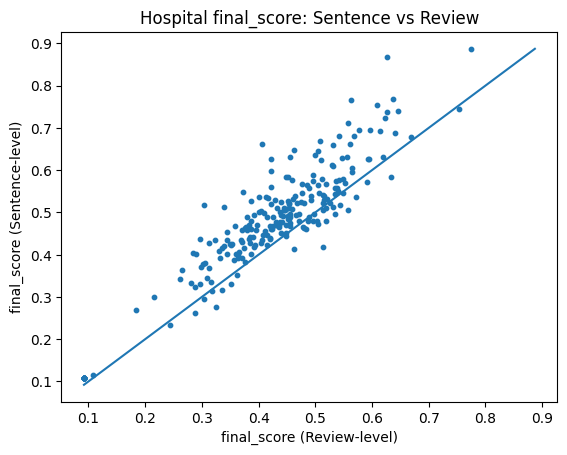


Saved review has_* agreement → /content/drive/MyDrive/hospital_aspect_outputs_p3_compare/review_hasflag_agreement.csv
           aspect  N_joined_reviews   tp   tn   fp  fn  agreement_rate  precision_sl_vs_rv  recall_sl_vs_rv  f1_sl_vs_rv
      cleanliness             11811 4710 4535 2100 209        0.782745            0.691630         0.957512     0.803138
    affordability             11811 5477 3315 2689  73        0.744391            0.670708         0.986847     0.798629
treatment_quality             11811 9337 1001 1161  55        0.875286            0.889408         0.994144     0.938864
  service_quality             11811 6221 3101 1808 424        0.789264            0.774816         0.936193     0.847894

Saved review aspect-sentiment comparison → /content/drive/MyDrive/hospital_aspect_outputs_p3_compare/review_aspect_sentiment_diff.csv
           aspect  N_where_SL_has_aspect  mean_diff(SL-RV)  median_diff  pct_diff_neg  pct_diff_zero  pct_diff_pos
      cleanliness         

In [ ]:
# Compare Review-level vs Sentence-level Results (Hospitals + Reviews)

!pip -q install pandas numpy matplotlib tqdm

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

# Review-level outputs (from your earlier zero-shot per-review pipeline)
RV_HOSP = "/content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot/hospital_scores_zeroshot.csv"
RV_REVS = "/content/drive/MyDrive/hospital_aspect_outputs_p3_zeroshot/reviews_with_zeroshot_aspects.csv"

# Sentence-level outputs (from the sentence-level pipeline)
SL_HOSP = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/hospital_scores_sentencelevel.csv"
SL_REVS = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/reviews_sentencelevel_aspects.csv"

OUT_DIR = "/content/drive/MyDrive/hospital_aspect_outputs_p3_compare"
os.makedirs(OUT_DIR, exist_ok=True)

ASPECTS = ["cleanliness","affordability","treatment_quality","service_quality"]
SHORT   = {"cleanliness":"C","affordability":"A","treatment_quality":"TQ","service_quality":"SQ"}

# ---------- Load ----------
rv_h = pd.read_csv(RV_HOSP)
sl_h = pd.read_csv(SL_HOSP)

rv_r = pd.read_csv(RV_REVS)
sl_r = pd.read_csv(SL_REVS)

# Create join keys
def add_hkey(df):
    key = df["Hospital"].astype(str)
    if "District" in df.columns:
        key = df["District"].astype(str) + " | " + key
    df = df.copy()
    df["HKEY"] = key
    return df

def add_rkey(df):
    key = df["Hospital"].astype(str) + " || " + df["Review"].astype(str)
    if "District" in df.columns:
        key = df["District"].astype(str) + " | " + key
    df = df.copy()
    df["RKEY"] = key
    return df

rv_h = add_hkey(rv_h)
sl_h = add_hkey(sl_h)

rv_r = add_rkey(rv_r)
sl_r = add_rkey(sl_r)

# ---------- HOSPITAL-LEVEL COMPARISON (PATCHED, no overlap) ----------
# We keep a single join key HKEY and suffix every other column.

keep_h_cols = ["HKEY","Hospital","N_reviews","S","C","A","TQ","SQ","conf","base_score","final_score"]

# Take only the columns we need
rvh = rv_h[[c for c in keep_h_cols if c in rv_h.columns]].copy()
slh = sl_h[[c for c in keep_h_cols if c in sl_h.columns]].copy()

# Suffix every column EXCEPT the join key 'HKEY'
rvh = rvh.rename(columns={c: f"{c}_rv" for c in rvh.columns if c != "HKEY"})
slh = slh.rename(columns={c: f"{c}_sl" for c in slh.columns if c != "HKEY"})

# Safe inner merge on HKEY (no overlapping names now)
H_cmp = rvh.merge(slh, on="HKEY", how="inner")

# Make a single readable Hospital name column (prefer sentence-level if present)
import pandas as pd
H_cmp["Hospital"] = H_cmp.get("Hospital_sl", pd.Series(index=H_cmp.index)).fillna(
    H_cmp.get("Hospital_rv", pd.Series(index=H_cmp.index))
)

# Ranks in each system (1 = best)
H_cmp["rank_rv"] = H_cmp["final_score_rv"].rank(ascending=False, method="min")
H_cmp["rank_sl"] = H_cmp["final_score_sl"].rank(ascending=False, method="min")
H_cmp["rank_change"] = H_cmp["rank_sl"] - H_cmp["rank_rv"]   # negative = moved up with sentence-level

# Deltas per aspect & overall
for col in ["S","C","A","TQ","SQ","base_score","final_score","conf","N_reviews"]:
    if f"{col}_rv" in H_cmp.columns and f"{col}_sl" in H_cmp.columns:
        H_cmp[f"delta_{col}"] = H_cmp[f"{col}_sl"] - H_cmp[f"{col}_rv"]

# Save and show biggest movers
hosp_cmp_path = os.path.join(OUT_DIR, "hospital_compare_sentence_vs_review.csv")
H_cmp.sort_values("final_score_sl", ascending=False).to_csv(hosp_cmp_path, index=False)
print("Saved hospital comparison →", hosp_cmp_path)

print("\n=== Biggest rank improvements (sentence-level vs review-level) ===")
print(
    H_cmp.sort_values("rank_change")
        .head(10)[["Hospital","rank_rv","rank_sl","rank_change","final_score_rv","final_score_sl"]]
        .to_string(index=False)
)

print("\n=== Biggest rank drops (sentence-level vs review-level) ===")
print(
    H_cmp.sort_values("rank_change", ascending=False)
        .head(10)[["Hospital","rank_rv","rank_sl","rank_change","final_score_rv","final_score_sl"]]
        .to_string(index=False)
)

# Correlations between systems
print("\n=== Pearson correlations (sentence vs review) ===")
for col in ["S","C","A","TQ","SQ","final_score"]:
    crv, csl = f"{col}_rv", f"{col}_sl"
    if crv in H_cmp.columns and csl in H_cmp.columns:
        import numpy as np
        print(f"{col:12s} : {np.corrcoef(H_cmp[crv], H_cmp[csl])[0,1]:0.3f}")

# Scatter: final_score (Sentence vs Review)
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(H_cmp["final_score_rv"], H_cmp["final_score_sl"], s=10)
plt.xlabel("final_score (Review-level)")
plt.ylabel("final_score (Sentence-level)")
plt.title("Hospital final_score: Sentence vs Review")
mn = min(H_cmp["final_score_rv"].min(), H_cmp["final_score_sl"].min())
mx = max(H_cmp["final_score_rv"].max(), H_cmp["final_score_sl"].max())
plt.plot([mn, mx], [mn, mx]); plt.show()

# ---------- REVIEW-LEVEL COMPARISON ----------
# Merge per-review frames (inner join by (District|)Hospital + Review text)
rv_cols = ["RKEY","Hospital","Review"] + [f"has_{a}" for a in ASPECTS] + [f"{a}_sentiment" for a in ASPECTS]
sl_cols = ["RKEY","Hospital","Review"] + [f"has_{a}" for a in ASPECTS] + [f"{a}_sentiment" for a in ASPECTS]
rv_small = rv_r[[c for c in rv_cols if c in rv_r.columns]].copy()
sl_small = sl_r[[c for c in sl_cols if c in sl_r.columns]].copy()

rv_small = rv_small.add_suffix("_rv"); rv_small.rename(columns={"RKEY_rv":"RKEY"}, inplace=True)
sl_small = sl_small.add_suffix("_sl"); sl_small.rename(columns={"RKEY_sl":"RKEY"}, inplace=True)

R_cmp = rv_small.merge(sl_small, on="RKEY", how="inner", suffixes=("",""))

# Agreement stats: has_* flags
agg_rows = []
for asp in ASPECTS:
    r = {}
    r["aspect"] = asp
    rv_flag = f"has_{asp}_rv"
    sl_flag = f"has_{asp}_sl"
    both = len(R_cmp)
    tp = int(((R_cmp[rv_flag]==1) & (R_cmp[sl_flag]==1)).sum())
    tn = int(((R_cmp[rv_flag]==0) & (R_cmp[sl_flag]==0)).sum())
    fp = int(((R_cmp[rv_flag]==0) & (R_cmp[sl_flag]==1)).sum())
    fn = int(((R_cmp[rv_flag]==1) & (R_cmp[sl_flag]==0)).sum())
    r["N_joined_reviews"] = both
    r["tp"], r["tn"], r["fp"], r["fn"] = tp, tn, fp, fn
    r["agreement_rate"] = (tp + tn) / both if both else np.nan
    # simple F1 where sentence-level is "prediction", review-level is "reference"
    prec = tp / (tp + fp) if (tp+fp) else np.nan
    rec  = tp / (tp + fn) if (tp+fn) else np.nan
    r["precision_sl_vs_rv"] = prec
    r["recall_sl_vs_rv"] = rec
    r["f1_sl_vs_rv"] = (2*prec*rec)/(prec+rec) if (prec and rec) else np.nan
    agg_rows.append(r)

has_agree = pd.DataFrame(agg_rows)
has_agree_path = os.path.join(OUT_DIR, "review_hasflag_agreement.csv")
has_agree.to_csv(has_agree_path, index=False)
print("\nSaved review has_* agreement →", has_agree_path)
print(has_agree.to_string(index=False))

# Aspect sentiment differences (only where sentence-level says aspect present)
sent_rows = []
for asp in ASPECTS:
    rv_col = f"{asp}_sentiment_rv"
    sl_col = f"{asp}_sentiment_sl"
    mask = R_cmp[f"has_{asp}_sl"] == 1
    sub = R_cmp.loc[mask, [rv_col, sl_col]].copy()
    if len(sub):
        diff = (sub[sl_col] - sub[rv_col]).astype(float)
        sent_rows.append({
            "aspect": asp,
            "N_where_SL_has_aspect": len(sub),
            "mean_diff(SL-RV)": diff.mean(),
            "median_diff": diff.median(),
            "pct_diff_neg": (diff < 0).mean(),
            "pct_diff_zero": (diff == 0).mean(),
            "pct_diff_pos": (diff > 0).mean()
        })
sent_aggr = pd.DataFrame(sent_rows)
sent_aggr_path = os.path.join(OUT_DIR, "review_aspect_sentiment_diff.csv")
sent_aggr.to_csv(sent_aggr_path, index=False)
print("\nSaved review aspect-sentiment comparison →", sent_aggr_path)
print(sent_aggr.to_string(index=False))

# A few examples where methods disagree on a flag (optional preview)
def show_disagreements(asp, n=5):
    rv_flag = f"has_{asp}_rv"; sl_flag = f"has_{asp}_sl"
    ex = R_cmp[(R_cmp[rv_flag]!=R_cmp[sl_flag])][[f"Hospital_rv", f"Review_rv", rv_flag, sl_flag]].head(n)
    if len(ex):
        print(f"\nExamples of disagreements for '{asp}':")
        print(ex.to_string(index=False)[:2000])

for asp in ASPECTS:
    show_disagreements(asp, n=3)

print("\nAll comparison CSVs saved in:", OUT_DIR)


In [ ]:
# Sentence-level ranking with MIN reviews filter (re-normalized on the subset)

import numpy as np, pandas as pd, os

MIN_REVIEWS = 5  # <<< change threshold here
OUT_DIR = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
os.makedirs(OUT_DIR, exist_ok=True)

# If 'H' isn't in memory (from sentence-level pipeline), load it:
try:
    H  # noqa: F821
except NameError:
    H = pd.read_csv(f"{OUT_DIR}/hospital_scores_sentencelevel.csv")

# 1) Filter to hospitals with at least MIN_REVIEWS
H_filt = H[H["N_reviews"] >= MIN_REVIEWS].copy()

# 2) Re-normalize aspect scores on the filtered subset
#    (use raw_* computed earlier to avoid cascading min-max)
if not all(c in H_filt.columns for c in ["raw_C","raw_A","raw_TQ","raw_SQ"]):
    raise ValueError("Expected raw_* columns missing. Re-run the sentence-level aggregation cell first.")

def minmax_safe_ser(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0.0, index=s.index)

for short in ["C","A","TQ","SQ"]:
    H_filt[short] = minmax_safe_ser(H_filt[f"raw_{short}"])

# 3) Recompute confidence on the filtered set (0..1 based on N_reviews within subset)
H_filt["conf"] = np.log1p(H_filt["N_reviews"])
H_filt["conf"] = H_filt["conf"] / H_filt["conf"].max() if H_filt["conf"].max() > 0 else 0.0

# 4) Recompute scores & rank
w_S, w_C, w_A, w_TQ, w_SQ = 0.25, 0.20, 0.15, 0.25, 0.15  # weights sum to 1
alpha = 0.85  # confidence floor

H_filt["base_score"]  = (w_S*H_filt["S"] + w_C*H_filt["C"] + w_A*H_filt["A"] + w_TQ*H_filt["TQ"] + w_SQ*H_filt["SQ"])
H_filt["final_score"] = H_filt["base_score"] * (alpha + (1 - alpha)*H_filt["conf"])

H_ranked_min = H_filt.sort_values("final_score", ascending=False).reset_index(drop=True)

print(f"Hospitals kept (N_reviews ≥ {MIN_REVIEWS}): {len(H_ranked_min)}")
print("\nTop-10 (final_score) among filtered:")
print(H_ranked_min[["Hospital","N_reviews","S","C","A","TQ","SQ","conf","final_score"]].head(10).to_string(index=False))

# 5) Top-3 per aspect (among filtered & re-normalized)
def topk_by_col(df_, col, k=3):
    return df_.sort_values(col, ascending=False)[["Hospital","N_reviews",col,"S","conf","final_score"]].head(k)

print("\nTop-3 by Sentiment (S):");  print(topk_by_col(H_ranked_min, "S").to_string(index=False))
print("\nTop-3 by Cleanliness (C):");print(topk_by_col(H_ranked_min, "C").to_string(index=False))
print("\nTop-3 by Affordability (A):");print(topk_by_col(H_ranked_min, "A").to_string(index=False))
print("\nTop-3 by Treatment Quality (TQ):");print(topk_by_col(H_ranked_min, "TQ").to_string(index=False))
print("\nTop-3 by Service Quality (SQ):");print(topk_by_col(H_ranked_min, "SQ").to_string(index=False))

# 6) Save
out_csv = f"{OUT_DIR}/hospital_scores_sentencelevel_min{MIN_REVIEWS}.csv"
H_ranked_min.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


Hospitals kept (N_reviews ≥ 5): 204

Top-10 (final_score) among filtered:
                                                  Hospital  N_reviews        S        C        A       TQ       SQ     conf  final_score
                                   Amina Clinic & Hospital          7 0.928571 0.971429 0.784314 1.000000 0.883117 0.371188     0.839150
                             Sonia Nursing Home Unit- 2_11          9 1.000000 0.688889 0.866013 0.974947 1.000000 0.411020     0.830896
Manikganj Central Specialized Hospital And Research Centre          9 0.944444 1.000000 0.784314 0.961076 0.727273 0.411020     0.823330
                                   Trauma General Hospital          7 1.000000 0.914286 0.840336 0.898089 0.740260 0.371188     0.810101
                                      Doyel Medical Centre         10 0.800000 0.840000 1.000000 0.909554 0.818182 0.428034     0.793636
                                   নরসিংদী আধুনিক হাসপাতাল          5 0.900000 0.840000 0.823529 0.92738

NEW (NEED TO CHECK FURTHER)

In [ ]:
# ==== DISTILLATION: Train a fast student to mimic zero-shot teacher (multi-label aspect presence) ====

import os
os.environ["WANDB_DISABLED"] = "true"   # stop wandb auto-logging

!pip -q install -U transformers datasets accelerate

import numpy as np, pandas as pd, torch, inspect
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments)
import torch.nn as nn

# ---- Config ----
ASPECTS  = ["cleanliness","affordability","treatment_quality","service_quality"]
ZS_COLS  = [f"zs_{a}_score" for a in ASPECTS]
STUDENT_MODEL = "xlm-roberta-base"       # or: "distilbert-base-uncased" (faster EN-only)
OUT_DIR  = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
STU_DIR  = os.path.join(OUT_DIR, "student_model")
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(STU_DIR, exist_ok=True)

# ---- Load sentence table ----
try:
    df_s
except NameError:
    df_s = pd.read_csv(os.path.join(OUT_DIR, "sentences_with_aspects_and_sentiment.csv"))

assert "sentence" in df_s.columns
assert set(ZS_COLS).issubset(df_s.columns)

df_ = df_s[["sentence"] + ZS_COLS].dropna().copy()
df_["sample_weight"] = df_[ZS_COLS].mean(axis=1).clip(0.05, 1.0)

# Split
train_df, val_df = train_test_split(df_, test_size=0.1, random_state=42, shuffle=True)

# Tokenizer
tok = AutoTokenizer.from_pretrained(STUDENT_MODEL)

# Build HF datasets with SOFT LABELS under a single "labels" key (shape: 4)
def to_hf(ds: pd.DataFrame):
    return Dataset.from_pandas(
        ds.assign(labels=ds[ZS_COLS].values.tolist())[["sentence","labels","sample_weight"]],
        preserve_index=False
    )

train_hf = to_hf(train_df)
val_hf   = to_hf(val_df)

def enc_fn(batch):
    enc = tok(batch["sentence"], truncation=True, padding="max_length", max_length=192)
    enc["labels"] = batch["labels"]            # list[list[float]] -> tensor later
    enc["sample_weight"] = batch["sample_weight"]
    return enc

train_tok = train_hf.map(enc_fn, batched=True, remove_columns=train_hf.column_names)
val_tok   = val_hf.map(enc_fn,   batched=True, remove_columns=val_hf.column_names)

# Keep only the tensors we need
train_tok = train_tok.with_format("torch", columns=["input_ids","attention_mask","labels","sample_weight"])
val_tok   = val_tok.with_format("torch", columns=["input_ids","attention_mask","labels","sample_weight"])

# Model: multi-label (num_labels = 4)
model = AutoModelForSequenceClassification.from_pretrained(
    STUDENT_MODEL, num_labels=len(ASPECTS), problem_type="multi_label_classification"
)

# Custom Trainer that uses BCEWithLogits + sample weights
class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")         # (B, 4) FloatTensor
        weights = inputs.pop("sample_weight", None)
        outputs = model(**inputs)
        logits  = outputs.logits               # (B, 4)

        loss_fct = nn.BCEWithLogitsLoss(reduction="none")
        loss_per_label  = loss_fct(logits, labels)
        loss_per_sample = loss_per_label.mean(dim=1)

        if weights is None:
            weights = torch.ones_like(loss_per_sample, device=loss_per_sample.device)
        elif not isinstance(weights, torch.Tensor):
            weights = torch.tensor(weights, dtype=loss_per_sample.dtype, device=loss_per_sample.device)
        else:
            weights = weights.to(loss_per_sample.device)

        loss = (loss_per_sample * weights).mean()
        return (loss, outputs) if return_outputs else loss

# Metrics (self-check vs teacher at 0.5)
def compute_metrics(p):
    logits = p.predictions
    labels = p.label_ids
    probs  = 1/(1+np.exp(-logits))
    preds  = (probs >= 0.5).astype(int)
    y_true = labels.reshape(-1)
    y_pred = preds.reshape(-1)
    tp = (y_true*y_pred).sum()
    fp = ((1-y_true)*y_pred).sum()
    fn = (y_true*(1-y_pred)).sum()
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    f1 = 2*prec*rec/(prec+rec+1e-9)
    return {"micro_f1@0.5": float(f1), "precision": float(prec), "recall": float(rec)}

# TrainingArguments (version-safe) – IMPORTANT: keep remove_unused_columns=False
import transformers
print("Transformers:", transformers.__version__)

ta_kwargs = dict(
    output_dir=os.path.join(STU_DIR, "runs"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    remove_unused_columns=False,  # <— keeps 'labels' and 'sample_weight'
)

sig = inspect.signature(TrainingArguments.__init__)
if "evaluation_strategy" in sig.parameters:
    ta_kwargs.update(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="micro_f1@0.5",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available() if "fp16" in sig.parameters else False,
    )
else:
    if "evaluate_during_training" in sig.parameters:
        ta_kwargs["evaluate_during_training"] = True
    if "save_steps" in sig.parameters:
        ta_kwargs["save_steps"] = 500
    if "eval_steps" in sig.parameters:
        ta_kwargs["eval_steps"] = 500
    if "fp16" in sig.parameters:
        ta_kwargs["fp16"] = torch.cuda.is_available()

args = TrainingArguments(**ta_kwargs)

# Build trainer (no need for label_names hack now)
trainer = WeightedBCETrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(STU_DIR)
tok.save_pretrained(STU_DIR)
print("Saved student model to:", STU_DIR)

# Quick sanity
test_sents = [
    "Doctor was excellent but the billing was too high.",
    "Ward was clean and the nurses were polite.",
    "We waited two hours in queue; reception was rude."
]
enc = tok(test_sents, padding=True, truncation=True, max_length=192, return_tensors="pt").to(model.device)
probs = torch.sigmoid(model(**enc).logits).detach().cpu().numpy()
print("\nStudent probs (C, A, TQ, SQ):")
for s, p in zip(test_sents, probs):
    print(f"{s}\n  -> {np.round(p,3)}")


Map:   0%|          | 0/23289 [00:00<?, ? examples/s]

Map:   0%|          | 0/2588 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Transformers: 4.56.2


Step,Training Loss
50,0.254000
100,0.243700
150,0.230200
200,0.210800
250,0.216300
300,0.215400
350,0.207300
400,0.210400
450,0.205900
500,0.209700


Saved student model to: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/student_model

Student probs (C, A, TQ, SQ):
Doctor was excellent but the billing was too high.
  -> [0.017 0.986 0.925 0.514]
Ward was clean and the nurses were polite.
  -> [0.984 0.069 0.94  0.855]
We waited two hours in queue; reception was rude.
  -> [0.03  0.255 0.292 0.834]


In [ ]:
# ==== UNSUPERVISED THRESHOLDS per aspect: Otsu + (optional) GMM on logits ====

import os, numpy as np, pandas as pd
from sklearn.mixture import GaussianMixture

ASPECTS = ["cleanliness","affordability","treatment_quality","service_quality"]
ZS_COLS = [f"zs_{a}_score" for a in ASPECTS]
OUT_DIR = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"

try:
    df_s
except NameError:
    df_s = pd.read_csv(os.path.join(OUT_DIR, "sentences_with_aspects_and_sentiment.csv"))

scores = {a: df_s[f"zs_{a}_score"].dropna().clip(0,1).values for a in ASPECTS}

def otsu_threshold(xs, bins=400):
    xs = np.asarray(xs, dtype=float)
    xs = xs[(xs>=0) & (xs<=1)]
    hist, bin_edges = np.histogram(xs, bins=bins, range=(0,1), density=False)
    hist = hist.astype(float)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * (np.arange(bins) / (bins-1)))  # normalized bin centers in [0,1]
    mu_t = mu[-1]
    sigma_b2 = (mu_t*omega - mu)**2 / (omega*(1-omega) + 1e-12)
    idx = int(np.nanargmax(sigma_b2))
    t = bin_edges[idx]  # threshold at left edge of best bin
    return float(t)

def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def gmm_logit_threshold(xs, n_components=2):
    x = logit(np.asarray(xs, float)).reshape(-1,1)
    gm = GaussianMixture(n_components=n_components, covariance_type="full", random_state=0).fit(x)
    # find crossing point where weighted pdfs equal
    means = gm.means_.flatten(); vars_ = gm.covariances_.flatten(); weights = gm.weights_.flatten()
    # sort by mean
    order = np.argsort(means); means, vars_, weights = means[order], vars_[order], weights[order]
    # binary search on logit domain
    lo, hi = x.min(), x.max()
    for _ in range(60):
        mid = 0.5*(lo+hi)
        # gaussian pdfs
        f0 = weights[0] * (1/np.sqrt(2*np.pi*vars_[0])) * np.exp(-(mid-means[0])**2/(2*vars_[0]))
        f1 = weights[1] * (1/np.sqrt(2*np.pi*vars_[1])) * np.exp(-(mid-means[1])**2/(2*vars_[1]))
        if f0 < f1:
            lo = mid
        else:
            hi = mid
    t_logit = 0.5*(lo+hi)
    # map back to prob
    t = 1/(1+np.exp(-t_logit))
    return float(t)

tau_otsu = {a: otsu_threshold(scores[a]) for a in ASPECTS}
# GMM can fail if distribution is unimodal; wrap safely
tau_gmm = {}
for a in ASPECTS:
    try:
        tau_gmm[a] = gmm_logit_threshold(scores[a])
    except Exception:
        tau_gmm[a] = np.nan

tau_df = pd.DataFrame({
    "aspect": ASPECTS,
    "tau_otsu": [tau_otsu[a] for a in ASPECTS],
    "tau_gmm":  [tau_gmm[a]  for a in ASPECTS],
}).round(4)

print("Unsupervised thresholds (Otsu and GMM-logit):")
print(tau_df.to_string(index=False))

tau_path = os.path.join(OUT_DIR, "unsupervised_thresholds.csv")
tau_df.to_csv(tau_path, index=False)
print("\nSaved:", tau_path)

# --- How to apply new thresholds to rebuild has_* flags (in-place) ---
USE = "tau_otsu"   # or "tau_gmm" if valid
for _, row in tau_df.iterrows():
    asp = row["aspect"]; thr = float(row[USE]) if not np.isnan(row[USE]) else 0.40
    df_s[f"has_{asp}"] = (df_s[f"zs_{asp}_score"] >= thr).astype(int)

# Save a copy if you want
df_s.to_csv(os.path.join(OUT_DIR, f"sentences_with_aspects_and_sentiment_{USE}.csv"), index=False)
print("\nRebuilt has_* using", USE, "and saved updated sentence file.")


Unsupervised thresholds (Otsu and GMM-logit):
           aspect  tau_otsu  tau_gmm
      cleanliness    0.3875   0.9996
    affordability    0.4075   0.9993
treatment_quality    0.5125   0.9995
  service_quality    0.3375   0.9993

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/unsupervised_thresholds.csv

Rebuilt has_* using tau_otsu and saved updated sentence file.


In [ ]:
# ==== FAST INFERENCE with DISTILLED STUDENT (replaces zero-shot step) ====
# Runs student on sentences -> has_* -> review -> hospital (>=5 reviews) and saves outputs.

!pip -q install transformers

import os, numpy as np, pandas as pd, torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---- Paths (edit if yours differ) ----
BASE_DIR   = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
STU_DIR    = f"{BASE_DIR}/student_model"  # where you saved the trained student
SENTS_CSV  = f"{BASE_DIR}/sentences_with_aspects_and_sentiment.csv"  # from your sentence-level run
REV_CSV    = f"{BASE_DIR}/reviews_sentencelevel_aspects.csv"         # for rid, Hospital, Sentiment
TAU_CSV    = f"{BASE_DIR}/unsupervised_thresholds.csv"               # optional (Otsu/GMM)
OUT_DIR    = BASE_DIR

ASPECTS = ["cleanliness","affordability","treatment_quality","service_quality"]
MIN_REVIEWS = 5
USE_TAU = "tau_otsu"   # if TAU_CSV exists; else defaults to 0.50

# ---- Load inputs ----
# sentences with 'rid','Hospital','sentence' and 'sentiment_sentence'
try:
    df_s
except NameError:
    df_s = pd.read_csv(SENTS_CSV)

# reviews with 'rid','Hospital','Sentiment' (and maybe District)
try:
    df_reviews_base = pd.read_csv(REV_CSV)[["rid","Hospital","Sentiment","District"]]
except Exception:
    df_reviews_base = pd.read_csv(REV_CSV)[["rid","Hospital","Sentiment"]]

# ---- Load thresholds (optional) ----
tau = {a: 0.50 for a in ASPECTS}  # default (student probs are well-calibrated around 0.5)
if os.path.exists(TAU_CSV):
    taus = pd.read_csv(TAU_CSV).set_index("aspect")
    for a in ASPECTS:
        if USE_TAU in taus.columns and pd.notna(taus.loc[a, USE_TAU]):
            tau[a] = float(taus.loc[a, USE_TAU])

print("Using thresholds:", tau)

# ---- Load student model ----
tok = AutoTokenizer.from_pretrained(STU_DIR)
stu = AutoModelForSequenceClassification.from_pretrained(STU_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
stu.to(device); stu.eval()

# ---- Student inference on sentences ----
def student_probs(texts, batch_size=64, max_length=192):
    probs_all = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Student inference (sentences)"):
        batch = texts[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = stu(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()  # shape (B, 4)
        probs_all.append(probs)
    return np.vstack(probs_all) if probs_all else np.zeros((0,4))

probs = student_probs(df_s["sentence"].tolist())
for j, a in enumerate(ASPECTS):
    df_s[f"stu_{a}_prob"] = probs[:, j]
    df_s[f"has_{a}"] = (df_s[f"stu_{a}_prob"] >= tau[a]).astype(int)

# ---- Aggregate sentence -> review (reuse sentence-level sentiment) ----
def agg_review_aspects(df_s):
    rows = []
    for rid, sub in df_s.groupby("rid"):
        rec = {"rid": rid}
        for a in ASPECTS:
            mask = sub[f"has_{a}"] == 1
            rec[f"has_{a}"] = 1 if mask.any() else 0
            rec[f"{a}_sentiment"] = float(sub.loc[mask, "sentiment_sentence"].mean()) if mask.any() else 0.0
        rows.append(rec)
    return pd.DataFrame(rows)

rev_aspects = agg_review_aspects(df_s)
df_aspects = df_reviews_base.merge(rev_aspects, on="rid", how="left")

# ---- Compute hospital table ----
def minmax_safe(s: pd.Series):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0.0, index=s.index)

def compute_hospital_table(df_):
    g = df_.groupby("Hospital", dropna=False)
    rows = []
    for hosp, sub in g:
        N = len(sub)
        avg_sent = sub["Sentiment"].mean() if N>0 else 0.0
        S = (avg_sent + 1.0)/2.0
        rec = {"Hospital": hosp, "N_reviews": N, "S": S}
        for asp, short in [("cleanliness","C"),("affordability","A"),("treatment_quality","TQ"),("service_quality","SQ")]:
            mention = sub[f"has_{asp}"].sum()
            mention_frac = (mention / N) if N>0 else 0.0
            avg_as = sub.loc[sub[f"has_{asp}"]==1, f"{asp}_sentiment"].mean() if mention>0 else 0.0
            raw = mention_frac * ((avg_as + 1.0)/2.0)
            rec[f"raw_{short}"] = raw
            rec[f"{short}_mention_frac"] = mention_frac
        rows.append(rec)
    H = pd.DataFrame(rows)
    for short in ["C","A","TQ","SQ"]:
        H[short] = minmax_safe(H[f"raw_{short}"])
    H["conf"] = np.log1p(H["N_reviews"])
    H["conf"] = H["conf"] / H["conf"].max() if H["conf"].max() > 0 else 0.0
    return H

H = compute_hospital_table(df_aspects)

# ---- Filter to >= 5 reviews and re-normalize within subset ----
H_filt = H[H["N_reviews"] >= MIN_REVIEWS].copy()
def _mm(s): s = s.astype(float); return (s - s.min())/(s.max()-s.min()) if s.max()>s.min() else pd.Series(0.0, index=s.index)
for short in ["C","A","TQ","SQ"]:
    H_filt[short] = _mm(H_filt[f"raw_{short}"])

# ---- Recompute scores & ranking ----
w_S, w_C, w_A, w_TQ, w_SQ = 0.25, 0.20, 0.15, 0.25, 0.15
alpha = 0.85
H_filt["base_score"]  = (w_S*H_filt["S"] + w_C*H_filt["C"] + w_A*H_filt["A"] + w_TQ*H_filt["TQ"] + w_SQ*H_filt["SQ"])
H_filt["final_score"] = H_filt["base_score"] * (alpha + (1 - alpha)*H_filt["conf"])
H_ranked = H_filt.sort_values("final_score", ascending=False).reset_index(drop=True)

print(f"Hospitals kept (N_reviews ≥ {MIN_REVIEWS}): {len(H_ranked)}")
print(H_ranked[["Hospital","N_reviews","S","C","A","TQ","SQ","conf","final_score"]].head(10).to_string(index=False))

# ---- Save outputs (student-based) ----
df_s.to_csv(f"{OUT_DIR}/sentences_student_probs.csv", index=False)
df_aspects.to_csv(f"{OUT_DIR}/reviews_sentencelevel_aspects_student.csv", index=False)
H_ranked.to_csv(f"{OUT_DIR}/hospital_scores_sentencelevel_student_min{MIN_REVIEWS}.csv", index=False)
print("\nSaved:")
print(f"{OUT_DIR}/sentences_student_probs.csv")
print(f"{OUT_DIR}/reviews_sentencelevel_aspects_student.csv")
print(f"{OUT_DIR}/hospital_scores_sentencelevel_student_min{MIN_REVIEWS}.csv")


Using thresholds: {'cleanliness': 0.3875, 'affordability': 0.4075, 'treatment_quality': 0.5125, 'service_quality': 0.3375}


Student inference (sentences): 100%|██████████| 405/405 [00:18<00:00, 22.12it/s]


Hospitals kept (N_reviews ≥ 5): 204
                                                  Hospital  N_reviews        S        C        A       TQ       SQ     conf  final_score
                                   Amina Clinic & Hospital          7 0.928571 0.971429 0.784314 1.000000 1.000000 0.371188     0.855029
                             Sonia Nursing Home Unit- 2_11          9 1.000000 0.616667 0.866013 0.977589 0.933333 0.411020     0.809213
Manikganj Central Specialized Hospital And Research Centre          9 0.944444 0.955556 0.784314 0.842180 0.845833 0.411020     0.804342
                                      Doyel Medical Centre         10 0.800000 0.840000 1.000000 0.909554 0.892500 0.428034     0.803827
                                   Trauma General Hospital          7 1.000000 0.900000 0.756303 0.898089 0.712500 0.371188     0.792326
                           Kishoreganj Veterinary Hospital         21 0.880952 0.800000 0.784314 0.856476 0.812500 0.551763     0.777813
     

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/student_model/runs/plot_loss_train_eval.png


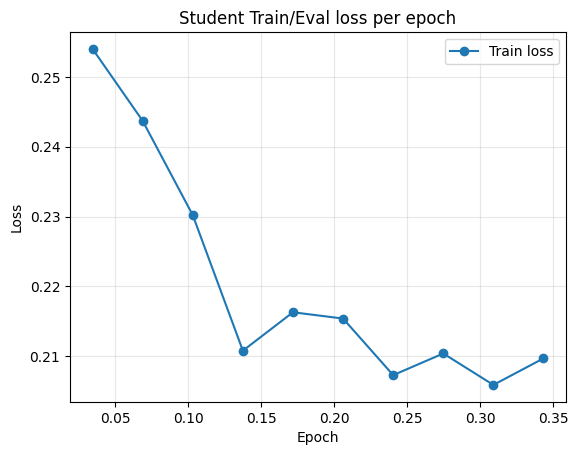

No eval_* metrics found; ensure evaluation_strategy='epoch' during training.


In [ ]:
# === Visualize Student Training: metrics vs epochs (F1 / Precision / Recall / Loss) ===
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Where your student model & run artifacts live
BASE_DIR = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
STU_DIR  = f"{BASE_DIR}/student_model"
RUNS_DIR = f"{STU_DIR}/runs"
os.makedirs(RUNS_DIR, exist_ok=True)

# 1) Load log_history either from in-memory trainer or from trainer_state.json
log_history = None
if 'trainer' in globals() and hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
    log_history = trainer.state.log_history

if not log_history:
    # Fallback: read trainer_state.json
    state_paths = glob.glob(os.path.join(RUNS_DIR, "trainer_state.json"))
    if not state_paths:
        # search recursively just in case
        state_paths = glob.glob(os.path.join(STU_DIR, "**", "trainer_state.json"), recursive=True)
    if not state_paths:
        raise FileNotFoundError("Could not find trainer_state.json. Re-run training or set STU_DIR correctly.")

    with open(state_paths[0], "r") as f:
        state = json.load(f)
    log_history = state.get("log_history", [])
    if not log_history:
        raise RuntimeError("trainer_state.json found, but has empty log_history. Re-run training with evaluation enabled.")

# 2) Convert to DataFrame and separate eval/train logs
logs = pd.DataFrame(log_history)

# Some rows are step logs (with "loss") and some are eval logs (keys start with 'eval_')
eval_cols = [c for c in logs.columns if c.startswith("eval_")]
train_cols = ["loss", "learning_rate", "epoch"]

eval_df = logs.dropna(subset=["epoch"])[["epoch"] + eval_cols].dropna(how="all", subset=eval_cols).copy()
train_df = logs.dropna(subset=["epoch"])[["epoch","loss"]].dropna(subset=["loss"]).copy()

# For loss, keep the last train loss per epoch (cleaner line)
train_last = (train_df.sort_values(["epoch"])
                      .groupby("epoch", as_index=False)["loss"].last())

# 3) Pretty names for plotting
# Your compute_metrics returned: micro_f1@0.5, precision, recall
name_map = {
    "eval_micro_f1@0.5": "Eval micro-F1 @0.5",
    "eval_precision": "Eval precision",
    "eval_recall": "Eval recall",
    "eval_loss": "Eval loss"
}
for c in eval_cols:
    if c not in name_map:
        name_map[c] = c.replace("eval_", "Eval ").replace("_", " ").title()

# 4) Plot helpers
def save_show(fig, outname):
    out_path = os.path.join(RUNS_DIR, outname)
    fig.savefig(out_path, bbox_inches="tight", dpi=140)
    print("Saved:", out_path)
    plt.show()

# 5) Plot: Eval micro-F1 across epochs
if "eval_micro_f1@0.5" in eval_df.columns:
    fig = plt.figure()
    plt.plot(eval_df["epoch"], eval_df["eval_micro_f1@0.5"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("micro-F1 @ 0.5")
    plt.title("Student Eval micro-F1 per epoch")
    plt.grid(True, alpha=0.3)
    save_show(fig, "plot_eval_micro_f1.png")

# 6) Plot: Eval precision & recall across epochs
prec_col = "eval_precision" if "eval_precision" in eval_df.columns else None
rec_col  = "eval_recall"    if "eval_recall" in eval_df.columns    else None
if prec_col or rec_col:
    fig = plt.figure()
    if prec_col: plt.plot(eval_df["epoch"], eval_df[prec_col], marker="o", label="Precision")
    if rec_col:  plt.plot(eval_df["epoch"], eval_df[rec_col],  marker="o", label="Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Student Eval precision/recall per epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_show(fig, "plot_eval_precision_recall.png")

# 7) Plot: Train vs Eval loss across epochs
has_eval_loss = "eval_loss" in eval_df.columns and eval_df["eval_loss"].notna().any()
if has_eval_loss or len(train_last):
    fig = plt.figure()
    if len(train_last):
        plt.plot(train_last["epoch"], train_last["loss"], marker="o", label="Train loss")
    if has_eval_loss:
        # Align epochs present in eval
        plt.plot(eval_df["epoch"], eval_df["eval_loss"], marker="o", label="Eval loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Student Train/Eval loss per epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_show(fig, "plot_loss_train_eval.png")

# 8) (Optional) Table summary for your slides
summary_cols = [c for c in ["eval_micro_f1@0.5", "eval_precision", "eval_recall", "eval_loss"] if c in eval_df.columns]
if summary_cols:
    print("\nEval summary per epoch:")
    display(eval_df[["epoch"] + summary_cols].round(4))
else:
    print("No eval_* metrics found; ensure evaluation_strategy='epoch' during training.")


Teacher thresholds in use: {'cleanliness': 0.3875, 'affordability': 0.4075, 'treatment_quality': 0.5125, 'service_quality': 0.3375}
Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_cleanliness.png


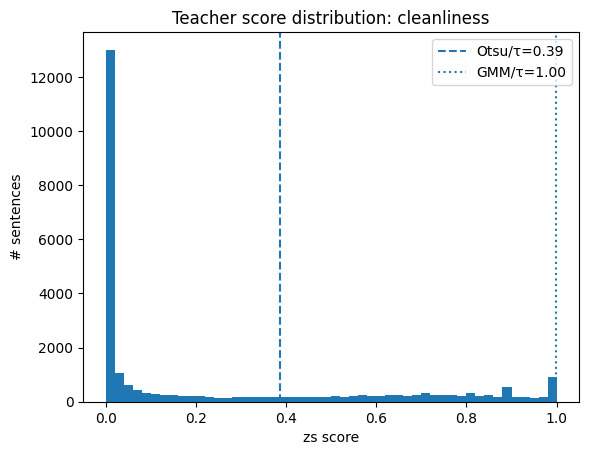

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_affordability.png


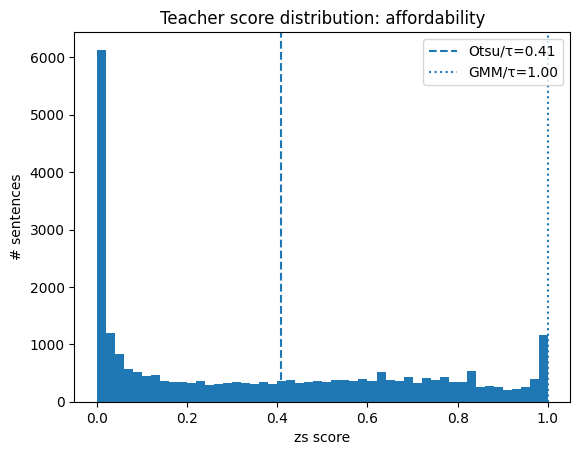

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_treatment_quality.png


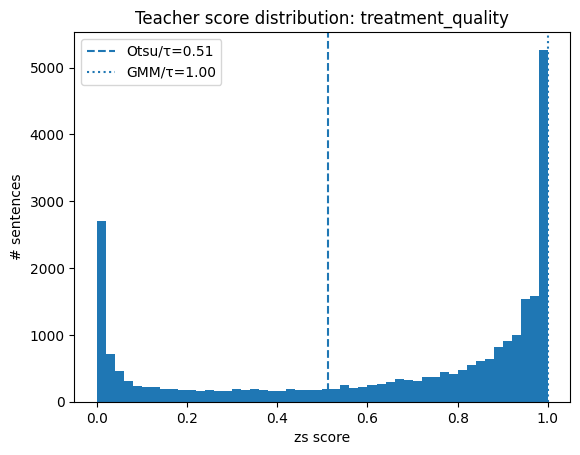

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_service_quality.png


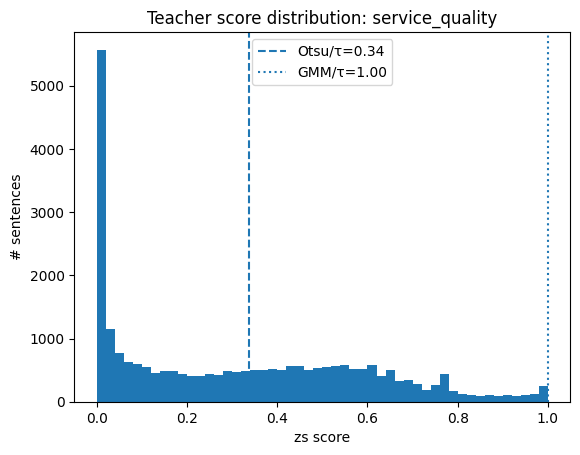

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_cleanliness.png


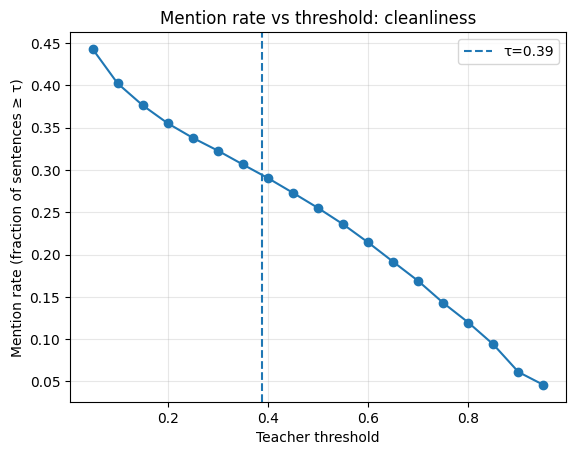

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_affordability.png


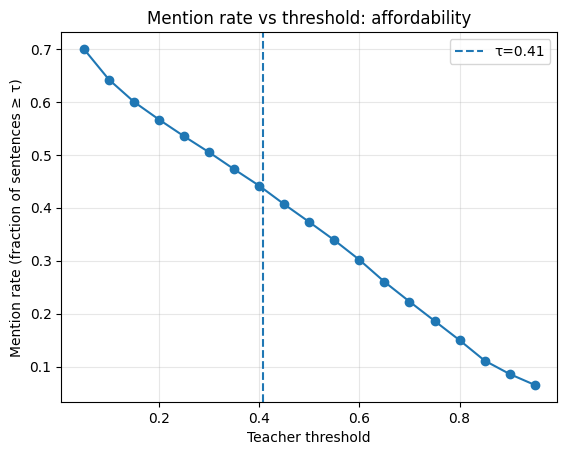

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_treatment_quality.png


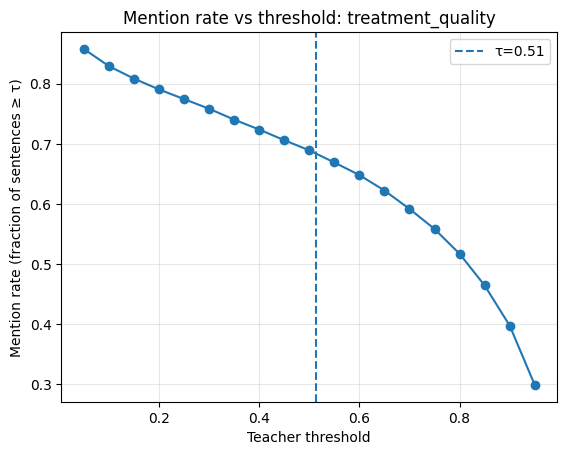

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_service_quality.png


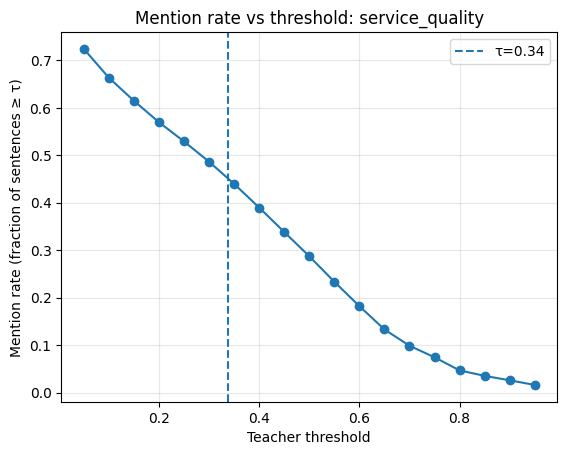


Student file found — building agreement plots (teacher vs student).
Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_agreement_cleanliness.png


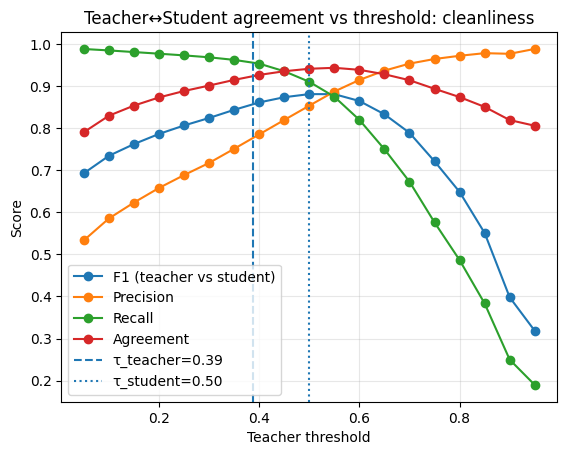

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_agreement_affordability.png


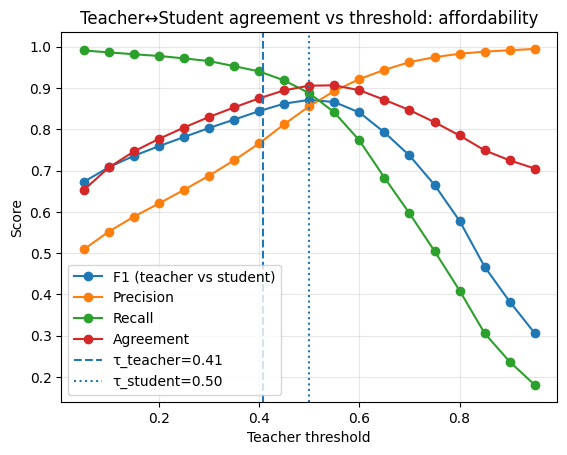

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_agreement_treatment_quality.png


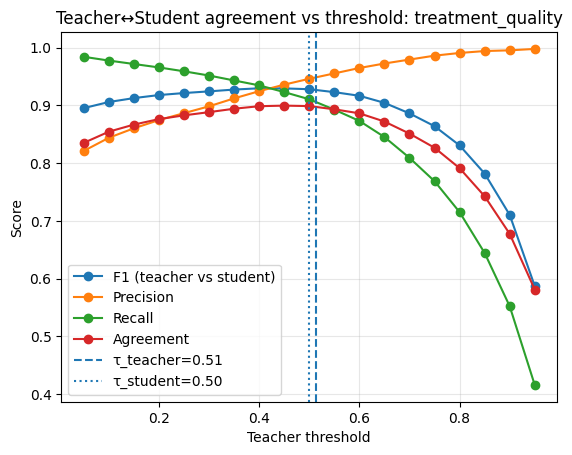

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_agreement_service_quality.png


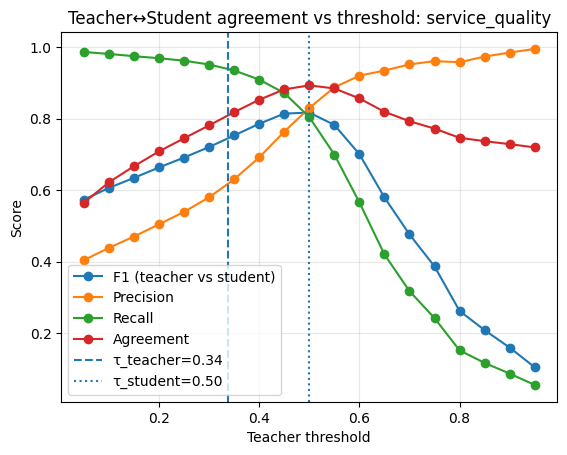

Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_scatter_cleanliness.png


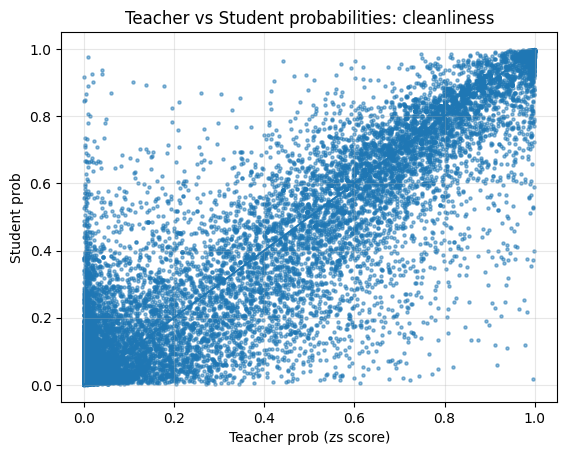

[cleanliness] Pearson corr (teacher vs student): 0.936
Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_scatter_affordability.png


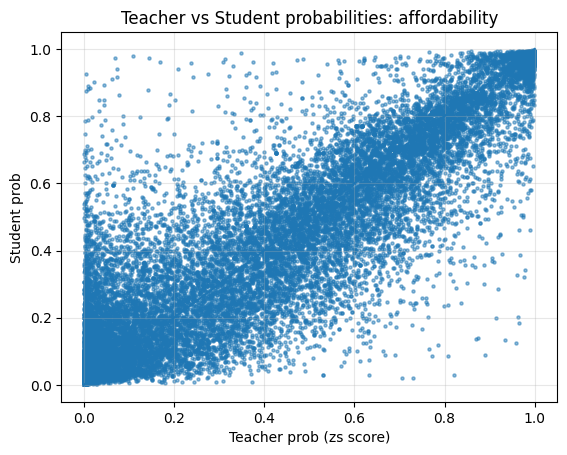

[affordability] Pearson corr (teacher vs student): 0.915
Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_scatter_treatment_quality.png


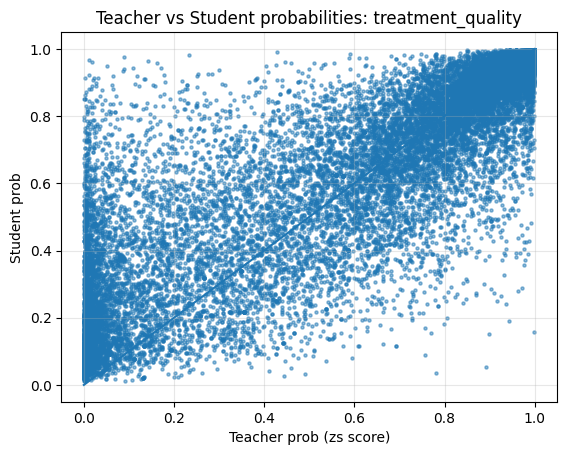

[treatment_quality] Pearson corr (teacher vs student): 0.895
Saved: /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_student_scatter_service_quality.png


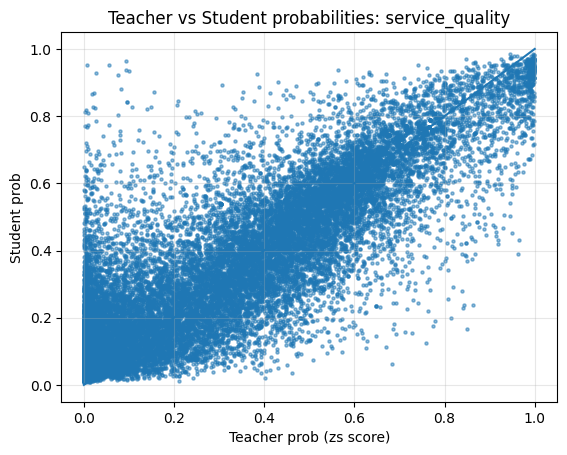

[service_quality] Pearson corr (teacher vs student): 0.875


In [ ]:
# === Teacher (zero-shot) Metrics Board + Teacher↔Student Agreement Visuals ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
TEACHER_SENTS = f"{BASE}/sentences_with_aspects_and_sentiment.csv"        # from sentence-level (teacher)
STUDENT_SENTS = f"{BASE}/sentences_student_probs.csv"                     # from student inference (optional)
TAU_CSV       = f"{BASE}/unsupervised_thresholds.csv"                     # optional thresholds
OUT_DIR       = f"{BASE}/viz_teacher"
os.makedirs(OUT_DIR, exist_ok=True)

ASPECTS = ["cleanliness","affordability","treatment_quality","service_quality"]

# --- Load teacher sentence-level table
dfT = pd.read_csv(TEACHER_SENTS)

# --- Optionally load student sentence-level probs (if available)
dfS = None
if os.path.exists(STUDENT_SENTS):
    dfS = pd.read_csv(STUDENT_SENTS)

# --- Load thresholds if present
tau = {a: 0.40 for a in ASPECTS}       # default teacher threshold (you can change)
tau_gmm = {a: np.nan for a in ASPECTS}
if os.path.exists(TAU_CSV):
    tdf = pd.read_csv(TAU_CSV).set_index("aspect")
    if "tau_otsu" in tdf.columns:
        for a in ASPECTS:
            if pd.notna(tdf.loc[a, "tau_otsu"]):
                tau[a] = float(tdf.loc[a, "tau_otsu"])
    if "tau_gmm" in tdf.columns:
        for a in ASPECTS:
            if pd.notna(tdf.loc[a, "tau_gmm"]):
                tau_gmm[a] = float(tdf.loc[a, "tau_gmm"])

print("Teacher thresholds in use:", tau)

# ---------- 1) Histograms of teacher zs scores with threshold lines ----------
for a in ASPECTS:
    x = dfT[f"zs_{a}_score"].dropna().clip(0,1).values
    if len(x) == 0:
        print(f"[{a}] no scores found");
        continue
    fig = plt.figure()
    plt.hist(x, bins=50, range=(0,1))
    # Threshold lines
    plt.axvline(tau[a], linestyle="--", label=f"Otsu/τ={tau[a]:.2f}")
    if not np.isnan(tau_gmm[a]):
        plt.axvline(tau_gmm[a], linestyle=":", label=f"GMM/τ={tau_gmm[a]:.2f}")
    plt.title(f"Teacher score distribution: {a}")
    plt.xlabel("zs score")
    plt.ylabel("# sentences")
    plt.legend()
    out = os.path.join(OUT_DIR, f"teacher_hist_{a}.png")
    plt.savefig(out, dpi=140, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

# ---------- 2) Mention rate vs threshold (teacher only) ----------
th_grid = np.linspace(0.05, 0.95, 19)
for a in ASPECTS:
    x = dfT[f"zs_{a}_score"].dropna().clip(0,1).values
    if len(x) == 0:
        continue
    rates = [(x >= th).mean() for th in th_grid]
    fig = plt.figure()
    plt.plot(th_grid, rates, marker="o")
    plt.axvline(tau[a], linestyle="--", label=f"τ={tau[a]:.2f}")
    plt.xlabel("Teacher threshold")
    plt.ylabel("Mention rate (fraction of sentences ≥ τ)")
    plt.title(f"Mention rate vs threshold: {a}")
    plt.grid(True, alpha=0.3); plt.legend()
    out = os.path.join(OUT_DIR, f"teacher_mention_curve_{a}.png")
    plt.savefig(out, dpi=140, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

# ---------- 3) Teacher ↔ Student agreement (if student available) ----------
if dfS is not None:
    print("\nStudent file found — building agreement plots (teacher vs student).")
    # Align rows; both files should be in the same order if built from the same df_s
    # If not, try a key merge on 'rid' + 'sentence' as a fallback:
    if "rid" in dfT.columns and "rid" in dfS.columns:
        try:
            # If lengths differ, do a safe merge
            if len(dfT) != len(dfS):
                dfM = pd.merge(dfT[["rid", "sentence"] + [f"zs_{a}_score" for a in ASPECTS]],
                               dfS[["rid", "sentence"] + [f"stu_{a}_prob" for a in ASPECTS]],
                               on=["rid","sentence"], how="inner")
            else:
                dfM = pd.concat([dfT.reset_index(drop=True), dfS[[f"stu_{a}_prob" for a in ASPECTS]].reset_index(drop=True)], axis=1)
        except Exception:
            dfM = pd.concat([dfT.reset_index(drop=True), dfS[[f"stu_{a}_prob" for a in ASPECTS]].reset_index(drop=True)], axis=1)
    else:
        dfM = pd.concat([dfT.reset_index(drop=True), dfS[[f"stu_{a}_prob" for a in ASPECTS]].reset_index(drop=True)], axis=1)

    # Student threshold (you can also load from TAU_CSV or set per-aspect)
    tau_student = {a: 0.50 for a in ASPECTS}

    # 3a) Agreement curves vs teacher threshold
    th_grid = np.linspace(0.05, 0.95, 19)
    for a in ASPECTS:
        tp=[]; fp=[]; fn=[]; f1=[]; prec=[]; rec=[]; agree=[]
        tprob = dfM[f"zs_{a}_score"].clip(0,1).values
        sprob = dfM[f"stu_{a}_prob"].clip(0,1).values
        sflag = (sprob >= tau_student[a]).astype(int)
        for th in th_grid:
            tflag = (tprob >= th).astype(int)
            tp_i = int(((tflag==1) & (sflag==1)).sum())
            tn_i = int(((tflag==0) & (sflag==0)).sum())
            fp_i = int(((tflag==1) & (sflag==0)).sum())
            fn_i = int(((tflag==0) & (sflag==1)).sum())
            prec_i = tp_i/(tp_i+fp_i+1e-9)
            rec_i  = tp_i/(tp_i+fn_i+1e-9)
            f1_i   = 2*prec_i*rec_i/(prec_i+rec_i+1e-9)
            agree_i = (tp_i+tn_i)/max(len(tflag),1)
            tp.append(tp_i); fp.append(fp_i); fn.append(fn_i); f1.append(f1_i)
            prec.append(prec_i); rec.append(rec_i); agree.append(agree_i)

        fig = plt.figure()
        plt.plot(th_grid, f1, marker="o", label="F1 (teacher vs student)")
        plt.plot(th_grid, prec, marker="o", label="Precision")
        plt.plot(th_grid, rec,  marker="o", label="Recall")
        plt.plot(th_grid, agree, marker="o", label="Agreement")
        plt.axvline(tau.get(a,0.4), linestyle="--", label=f"τ_teacher={tau.get(a,0.4):.2f}")
        plt.axvline(tau_student[a], linestyle=":", label=f"τ_student={tau_student[a]:.2f}")
        plt.xlabel("Teacher threshold")
        plt.ylabel("Score")
        plt.title(f"Teacher↔Student agreement vs threshold: {a}")
        plt.grid(True, alpha=0.3); plt.legend()
        out = os.path.join(OUT_DIR, f"teacher_student_agreement_{a}.png")
        plt.savefig(out, dpi=140, bbox_inches="tight")
        print("Saved:", out)
        plt.show()

    # 3b) Probability scatter + correlation per aspect
    for a in ASPECTS:
        tprob = dfM[f"zs_{a}_score"].clip(0,1).values
        sprob = dfM[f"stu_{a}_prob"].clip(0,1).values
        if len(tprob) == 0:
            continue
        fig = plt.figure()
        plt.scatter(tprob, sprob, s=5, alpha=0.5)
        plt.xlabel("Teacher prob (zs score)")
        plt.ylabel("Student prob")
        plt.title(f"Teacher vs Student probabilities: {a}")
        # 45° line
        mn = 0.0; mx = 1.0
        plt.plot([mn,mx],[mn,mx])
        plt.grid(True, alpha=0.3)
        out = os.path.join(OUT_DIR, f"teacher_student_scatter_{a}.png")
        plt.savefig(out, dpi=140, bbox_inches="tight")
        print("Saved:", out)
        plt.show()
        # Print correlation
        corr = np.corrcoef(tprob, sprob)[0,1]
        print(f"[{a}] Pearson corr (teacher vs student): {corr:.3f}")
else:
    print("\nStudent file not found — generated teacher-only plots. Run the student inference cell to enable agreement visuals.")


In [ ]:
# === Download all generated visuals (ZIP) ===
import os, glob, zipfile
from google.colab import files

BASE        = "/content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel"
TEACHER_DIR = f"{BASE}/viz_teacher"             # teacher & agreement plots
STU_DIR     = f"{BASE}/student_model"
RUNS_DIR    = f"{STU_DIR}/runs"                 # student training plots

# Collect visuals
teacher_pngs = glob.glob(os.path.join(TEACHER_DIR, "*.png"))
student_pngs = glob.glob(os.path.join(RUNS_DIR, "**", "*.png"), recursive=True)

selected = []
selected += teacher_pngs
selected += student_pngs

print("Found visuals:")
for p in selected:
    print(" -", p)

if not selected:
    raise SystemExit("No PNG visuals found. Make sure you've run the plotting cells first.")

# Make a tidy ZIP with relative paths
zip_path = "/content/p3_visuals.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in selected:
        # keep a readable folder structure inside the zip
        if p.startswith(BASE):
            arcname = os.path.relpath(p, BASE)
        else:
            arcname = os.path.basename(p)
        zf.write(p, arcname)

print("\nCreated:", zip_path)
files.download(zip_path)

# === (Optional) Download individual files instead of a zip ===
# for p in selected:
#     files.download(p)


Found visuals:
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_cleanliness.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_affordability.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_treatment_quality.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_hist_service_quality.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_cleanliness.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_affordability.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_treatment_quality.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentencelevel/viz_teacher/teacher_mention_curve_service_quality.png
 - /content/drive/MyDrive/hospital_aspect_outputs_p3_sentence

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>